# TCR–peptide ranking with peptide features, TCR features, and TCRen

This notebook gives an overview of the project and its main results.

## Goal
The goal of this project was to test whether simple engineered features can help rank candidate peptides for a given T cell receptor (TCR), and to compare these models with the structure-based TCRen baseline.

## What was done
Starting from the data released with the TCRen paper, I:

- built candidate peptide sets for individual TCR systems
- computed TCRen scores for each candidate peptide
- engineered peptide-derived features
- engineered TCR-derived features from CDR3α and CDR3β
- compared several models using repeated grouped train/test splits

## Models compared
- **TCRen baseline**
- **LogReg peptide**
- **RF peptide**
- **LogReg peptide+TCR**
- **RF peptide+TCR**
- **LogReg full**
- **RF full**

Here, **full** means:
- peptide features
- TCR features
- TCRen score

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
base = Path("../results")

results_csv = base / "repeated_eval_all_results_with_tcr.csv"
summary_csv = base / "repeated_eval_summary_with_tcr.csv"

results = pd.read_csv(results_csv)
summary = pd.read_csv(summary_csv)

print("Results shape:", results.shape)
print("Summary shape:", summary.shape)

Results shape: (210, 12)
Summary shape: (7, 17)


## Evaluation setup

The models were evaluated using repeated grouped train/test splits.

### Important detail
The split was done by **`pdb_id`**, not by random rows, so all candidate peptides for the same TCR system stayed together in either the training set or the test set.

This avoids leakage and makes the evaluation more realistic.

### Metrics used
Because this is mainly a ranking task, the most useful metrics are:

- **average precision**
- **MRR** (mean reciprocal rank)
- **top-1**
- **top-5**

Note that accuracy is included, although it is less useful in this particular case, since we are dealing with a highly imbalanced dataset.

In [3]:
show_cols = [
    "model",
    "avg_precision_mean", "avg_precision_std",
    "mrr_mean", "mrr_std",
    "top1_mean", "top1_std",
    "top5_mean", "top5_std",
]

summary[show_cols].sort_values("mrr_mean", ascending=False)

,model,avg_precision_mean,avg_precision_std,mrr_mean,mrr_std,top1_mean,top1_std,top5_mean,top5_std
3,rf_full,0.493245,0.143962,0.619702,0.146663,0.504167,0.168932,0.754167,0.165712
0,logreg_full,0.370765,0.122213,0.556221,0.131824,0.450000,0.159471,0.700000,0.148991
4,rf_peptide,0.358937,0.123449,0.509069,0.149128,0.387500,0.144400,0.666667,0.205876
5,rf_peptide_tcr,0.347725,0.132134,0.485441,0.150752,0.370833,0.159076,0.650000,0.211216
6,tcren_baseline,0.221983,0.110385,0.334269,0.084985,0.150000,0.095141,0.487500,0.140619
2,logreg_peptide_tcr,0.147129,0.061179,0.303491,0.104271,0.162500,0.119039,0.458333,0.155132
1,logreg_peptide,0.166393,0.075291,0.300919,0.101227,0.162500,0.114423,0.466667,0.163914


## Model names

For readability in the plots, I use the following labels:

- **TCRen** = TCRen baseline only
- **LogReg peptide** = logistic regression using peptide features
- **RF peptide** = random forest using peptide features
- **LogReg peptide+TCR** = logistic regression using peptide + TCR features
- **RF peptide+TCR** = random forest using peptide + TCR features
- **LogReg full** = peptide + TCR + TCRen
- **RF full** = peptide + TCR + TCRen

In [4]:
model_order = [
    "tcren_baseline",
    "logreg_peptide",
    "rf_peptide",
    "logreg_peptide_tcr",
    "rf_peptide_tcr",
    "logreg_full",
    "rf_full",
]

label_map = {
    "tcren_baseline": "TCRen",
    "logreg_peptide": "LogReg peptide",
    "rf_peptide": "RF peptide",
    "logreg_peptide_tcr": "LogReg peptide+TCR",
    "rf_peptide_tcr": "RF peptide+TCR",
    "logreg_full": "LogReg full",
    "rf_full": "RF full",
}

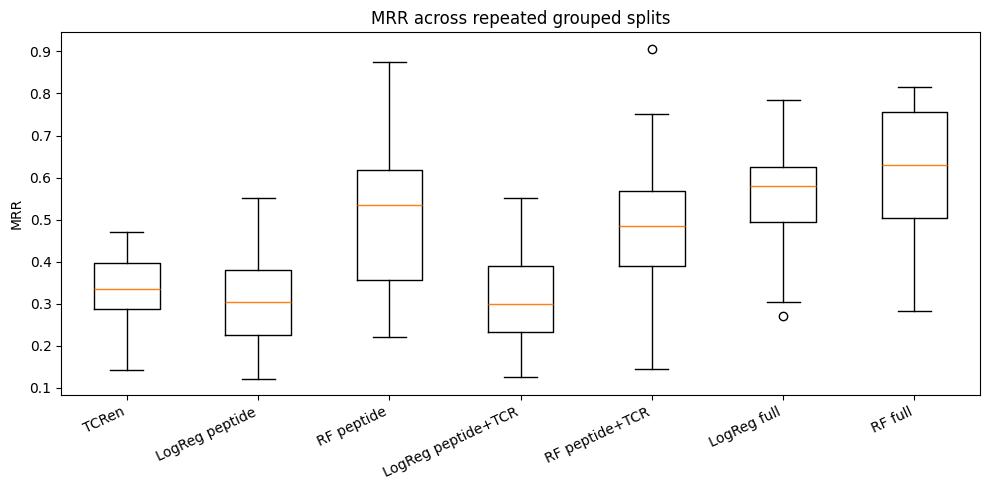

In [5]:
plt.figure(figsize=(10, 5))

data = [results.loc[results["model"] == m, "mrr"].values for m in model_order]

plt.boxplot(data, tick_labels=[label_map[m] for m in model_order])
plt.xticks(rotation=25, ha="right")
plt.ylabel("MRR")
plt.title("MRR across repeated grouped splits")
plt.tight_layout()
plt.show()

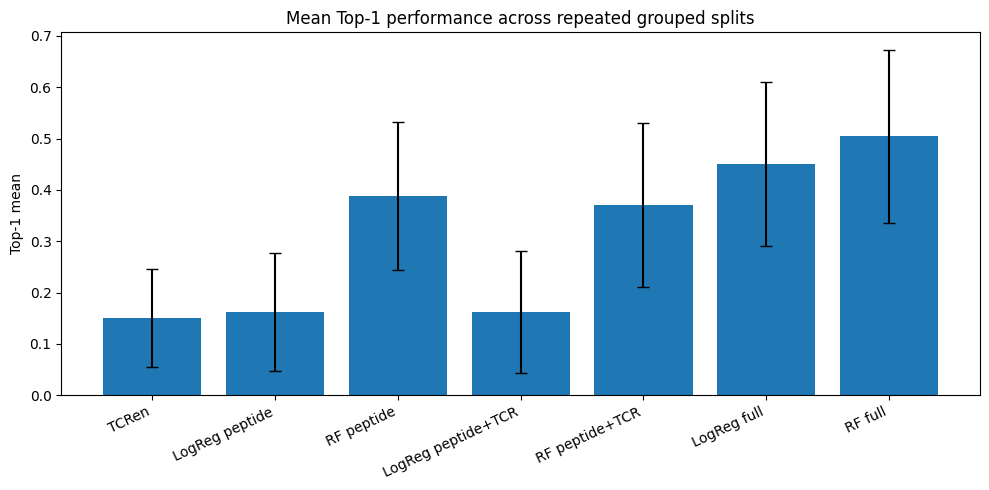

In [6]:
summary2 = summary.set_index("model").loc[model_order].reset_index()

plt.figure(figsize=(10, 5))
plt.bar(
    [label_map[m] for m in summary2["model"]],
    summary2["top1_mean"],
    yerr=summary2["top1_std"],
    capsize=4
)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Top-1 mean")
plt.title("Mean Top-1 performance across repeated grouped splits")
plt.tight_layout()
plt.show()

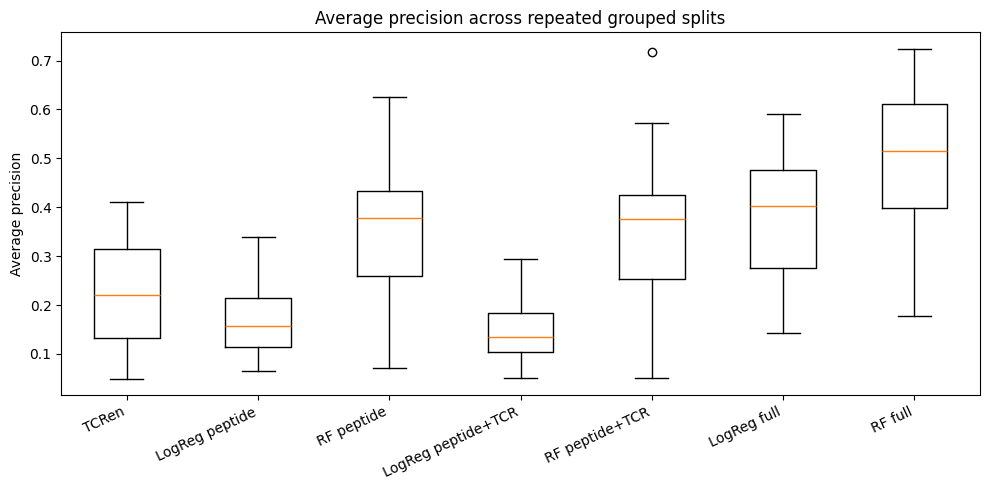

In [7]:
plt.figure(figsize=(10, 5))

data = [results.loc[results["model"] == m, "avg_precision"].values for m in model_order]

plt.boxplot(data, tick_labels=[label_map[m] for m in model_order])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Average precision")
plt.title("Average precision across repeated grouped splits")
plt.tight_layout()
plt.show()

## Interpretation of the results

The original evaluation shows strong performance for the full models, but the composition-matched control changes how the sequence-model results should be interpreted:

1. **Peptide-only models collapse to chance under composition matching.**  
   Their scores are tied within each TCR when the negatives preserve the cognate peptide's amino-acid composition and length. This indicates that the strong peptide-only performance on the original dataset was substantially dependent on the composition shortcut introduced by the negative-sampling procedure.

2. **Adding these simple TCR features does not rescue the matched-control ranking.**  
   The peptide+TCR models also produce tied within-TCR scores in the matched control. The particular hand-engineered CDR3 summaries therefore do not provide evidence of independent TCR-specific ranking signal in this experiment.

3. **The full Logistic Regression matches TCRen on the matched-control ranking metrics.**  
   Because the peptide features are constant within each TCR under the matched control, they cannot change the within-TCR ordering. The Random Forest is actually worse than TCRen alone on ranking (MRR 0.13 vs 0.28).

4. **The original full-model results remain useful as a prototype comparison, but they should not be read as clean evidence that simple sequence features independently capture TCR specificity.**  
   The matched negative control shows that dataset construction can create a substantial shortcut.

See `notebooks/inference_showcase.ipynb` for the model applied to held-out input, including a held-out ranking demo.

In [8]:
summary[[
    "model",
    "avg_precision_mean",
    "mrr_mean",
    "top1_mean",
    "top5_mean"
]].sort_values("mrr_mean", ascending=False)

,model,avg_precision_mean,mrr_mean,top1_mean,top5_mean
3,rf_full,0.493245,0.619702,0.504167,0.754167
0,logreg_full,0.370765,0.556221,0.450000,0.700000
4,rf_peptide,0.358937,0.509069,0.387500,0.666667
5,rf_peptide_tcr,0.347725,0.485441,0.370833,0.650000
6,tcren_baseline,0.221983,0.334269,0.150000,0.487500
2,logreg_peptide_tcr,0.147129,0.303491,0.162500,0.458333
1,logreg_peptide,0.166393,0.300919,0.162500,0.466667


## Main conclusion

In this prototype study, the strongest performance on the original dataset came from combining peptide features, TCR features, and the structure-based TCRen score. However, the composition-matched control shows that this performance cannot be interpreted simply as evidence that the sequence features learn TCR–peptide specificity.

The matched control removes the simple amino-acid-composition shortcut: peptide-only and peptide+TCR models collapse to tied, chance-level rankings, full Logistic Regression matches TCRen on ranking metrics, and Random Forest performs worse than TCRen alone. The main result is therefore a methodological one: **negative-set construction has a major effect on what these models appear to learn.**

The project is best viewed as a small, interpretable study of that failure mode and as a basis for testing more biologically realistic negative sets.

## Limitations

This is still a small prototype project, so the results should be interpreted with caution.

Main limitations:
- only 25 TCR systems were used
- negative peptides were randomly generated in the original evaluation
- candidate peptides were not structurally remodeled
- TCR features were simple engineered summaries rather than richer learned representations
- the composition-matched control is a useful stress test, but it does not replace evaluation on biologically realistic negative sets

## Possible next steps

Some useful follow-up directions would be:

- use more TCR systems
- generate more realistic negatives by preserving anchor residues
- add richer TCR sequence features
- test additional ranking models
- compare with more baselines

## Reference

This project was built using data derived from the repository accompanying:

**Karnaukhov VK, Shcherbinin DS, Chugunov AO, et al.**  
*Structure-based prediction of T cell receptor recognition of unseen epitopes using TCRen.*  
Nature Computational Science (2024).